In [ ]:
print("Car Damage Detection")

Car Damage Detection


In [ ]:
# Import necessary libraries
import os
import zipfile
import requests

# URL to your dataset zip file in the GitHub repository
dataset_url = 'https://raw.githubusercontent.com/rafdimilzano/data/main/cdadataset.zip'  # Change this URL to your dataset location

# Download the dataset
dataset_zip_path = 'cdadataset.zip'
response = requests.get(dataset_url)

# Save the zip file locally
with open(dataset_zip_path, 'wb') as file:
    file.write(response.content)

# Unzip the dataset
with zipfile.ZipFile(dataset_zip_path, 'r') as zip_ref:
    zip_ref.extractall('dataset')  # Extract the dataset into the 'dataset' folder

# Check the unzipped folder structure
os.listdir('dataset')


['training', 'validation']

In [ ]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random as python_random
import tensorflow as tf
import seaborn as sns
import math
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from tensorflow.keras.callbacks import ModelCheckpoint
from  tensorflow.keras.callbacks import EarlyStopping
from keras import backend as K
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Set dataset paths
train_dir = 'dataset/training'    # Path to the Training set
val_dir = 'dataset/validation'    # Path to the Validation set
image_size = (190, 190)  # Resize images to 190x190
batch_size = 32

# Image augmentation for the training set to improve generalization
train_datagen = ImageDataGenerator(
    rescale=1.0/255,            # Rescale pixel values to [0, 1]
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# No augmentation for validation data, only rescaling
val_datagen = ImageDataGenerator(rescale=1.0/255)

# Loading training data from the structured directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Loading validation data from the structured directories
validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)


Found 1383 images belonging to 3 classes.
Found 248 images belonging to 3 classes.


In [ ]:
resnet_base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(190, 190, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
for layer in resnet_base_model.layers:
    layer.trainable = False

In [ ]:
from tensorflow.keras import layers
num_classes = 3

# 3. Fine-tune the Model
# model = Sequential()
# model.add(base_model)
# # model.add(Flatten())
# # model.add(Dense(512, activation='relu'))
# # model.add(Dropout(0.5))
# # model.add(Dense(num_classes, activation='softmax'))

# model.add(GlobalAveragePooling2D())

# model.add(Flatten())
# model.add(Dense(256, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(256, activation='relu'))
# model.add(Dropout(0.5))

# #
# model.add(Dense(num_classes, activation='softmax'))

# resnetmodel = Sequential([
#     resnet_base_model,
#     Flatten(),
#     Dense(256, activation='relu'),
#     Dropout(0.5),
#     Dense(num_classes, activation='softmax')  # binary classification, so 1 neuron with sigmoid activation
# ])
# vggmodel = tf.keras.models.Model(resnetmodel.input, predictions)

last_output = resnet_base_model.output
x = layers.Flatten()(last_output)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
predictions = layers.Dense(num_classes, activation='softmax')(x)

resnetmodel = tf.keras.models.Model(resnet_base_model.input, predictions)

resnetmodel.compile(optimizer='adam',
              loss='CategoricalCrossentropy',
              metrics=['accuracy'])

resnetmodel.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 190, 190, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 196, 196, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 95, 95, 64)     │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 95, 95, 64)     │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 95, 95, 64)     │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 97, 97, 64)     │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 48, 48, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 48, 48, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 48, 48, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 48, 48, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 48, 48, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 48, 48, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 48, 48, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 48, 48, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 48, 48, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 42,463,107 (161.98 MB)

 Trainable params: 18,875,395 (72.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Try importing the callback from tensorflow.keras.callbacks
from tensorflow.keras.callbacks import EarlyStopping

# Define a callback to stop training when accuracy reaches a certain threshold
early_stopping = EarlyStopping(monitor='val_loss', patience=5, min_delta=0.005) #Example values for patience and min_delta

resnethist = resnetmodel.fit(
    train_generator,
    steps_per_epoch=40,
    epochs=20,
    validation_data=validation_generator,
    validation_steps=10,
    callbacks=[early_stopping]
    )

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


40/40 ━━━━━━━━━━━━━━━━━━━━ 250s 6s/step - accuracy: 0.3431 - loss: 3.1867 - val_accuracy: 0.5202 - val_loss: 1.0321
Epoch 2/20


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


40/40 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.3939 - loss: 1.0589 - val_accuracy: 0.5363 - val_loss: 1.0338
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 239s 6s/step - accuracy: 0.4167 - loss: 1.0648 - val_accuracy: 0.5484 - val_loss: 1.0282
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.4082 - loss: 1.0788 - val_accuracy: 0.5121 - val_loss: 1.0288
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 234s 6s/step - accuracy: 0.3762 - loss: 1.0669 - val_accuracy: 0.5726 - val_loss: 1.0104
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.4272 - loss: 1.0606 - val_accuracy: 0.5484 - val_loss: 1.0156
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 275s 6s/step - accuracy: 0.4178 - loss: 1.0608 - val_accuracy: 0.3669 - val_loss: 1.0340
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.3195 - loss: 1.0707 - val_accuracy: 0.3669 - val_loss: 1.0233
Epoch 9/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 237s 6s/step - accuracy: 0.3843 - loss: 1.0714 - val_accuracy: 0.4073 - val_loss: 1.0302

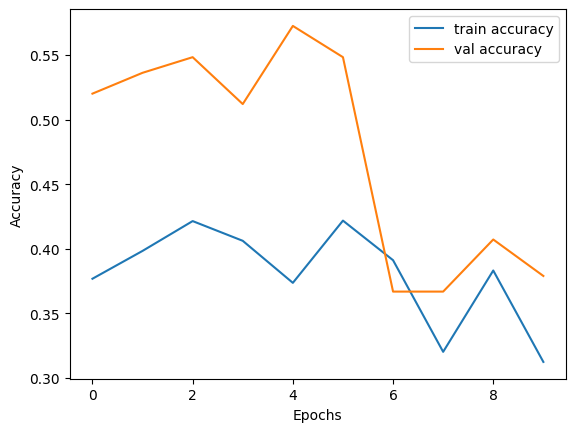

8/8 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.3588 - loss: 1.0317
Validation Accuracy: 37.90%


In [ ]:
# Plot the training history for accuracy
plt.plot(resnethist.history['accuracy'], label='train accuracy')
plt.plot(resnethist.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Evaluate the model on validation data
val_loss, val_acc = resnetmodel.evaluate(validation_generator)
print(f"Validation Accuracy: {val_acc*100:.2f}%")


In [ ]:
def classify_image(image_path, model):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=image_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Scale the image

    prediction = model.predict(img_array)
    class_labels = ['Minor', 'Moderate', 'Severe']
    return class_labels[np.argmax(prediction)]

# Test classification
# test_image = 'path_to_test_image'
# classification = classify_image(test_image, model)
# print(f"Damage Severity: {classification}")
